<a href="https://colab.research.google.com/github/machancejoy-max/colab-git-demo-JOY/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    

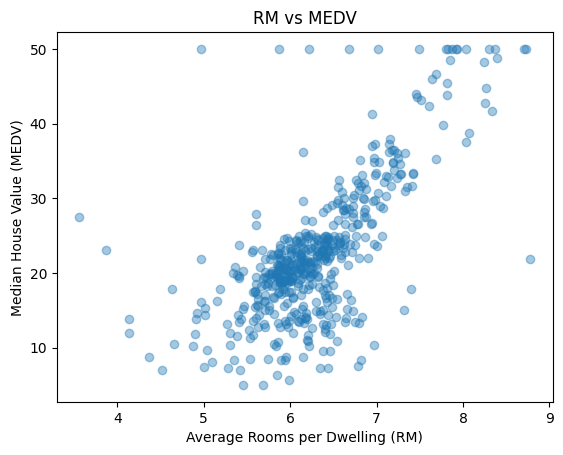

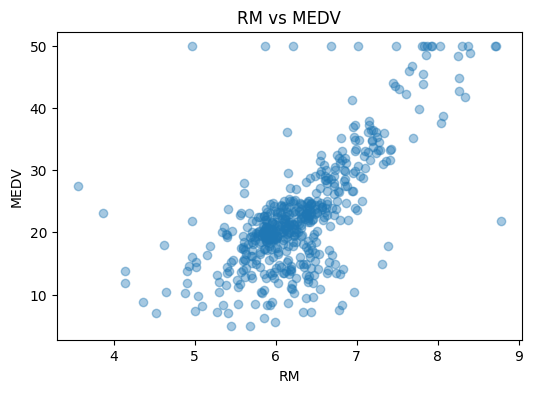

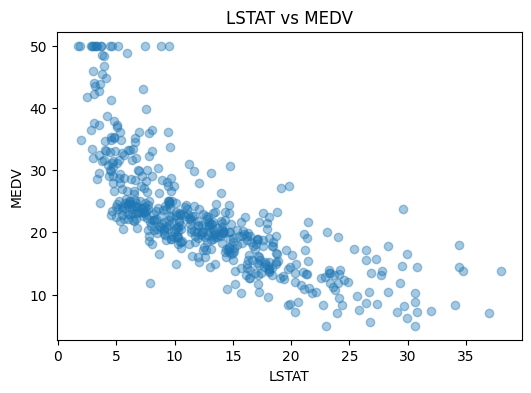

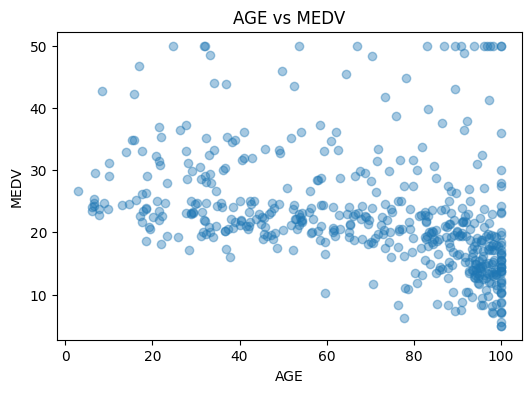

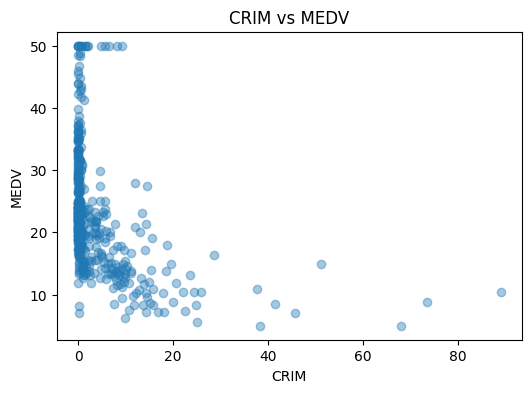

RMSE: 2.917224938728114
R-squared: 0.8839525117021145
Predicted House Price (MEDV): 22.31300000000001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Collection and Loading ---
# Load Boston Housing dataset from OpenML
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

# --- Quick Check of Data ---
print(df.head())        # First few rows
print(df.info())        # Data types
print(df.describe())    # Summary statistics

# --- EDA and Data Preprocessing ---
print(df.isnull().sum())  # Check missing values

# Example scatter plot
plt.scatter(df['RM'], df['MEDV'], alpha=0.4)
plt.xlabel("Average Rooms per Dwelling (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("RM vs MEDV")
plt.show()

# Function to automate scatter plots
def plot_feature_vs_target(df, features, target):
    for feature in features:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[feature], df[target], alpha=0.4)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.show()

# Use the function
features_to_plot = ['RM', 'LSTAT', 'AGE', 'CRIM']
plot_feature_vs_target(df, features_to_plot, 'MEDV')

# --- ML Model Training ---
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Choose a regression model (Random Forest recommended)
model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train the model
model.fit(X_train, y_train)

# --- Model Evaluation ---
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)

# --- Model Prediction ---
# Example new data
new_data = np.array([[0.2, 12.5, 7.07, 0, 0.5, 6.5, 68, 4.0, 2, 250, 17, 400, 12]])

prediction = model.predict(new_data)
print("Predicted House Price (MEDV):", prediction[0])